<a href="https://colab.research.google.com/github/pavlenkosasha/MillionaireAPI/blob/main/Uber_Pickups_in_New_York_City_PAVLENKO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1 — загрузка файла

In [4]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

2 — бібліотеки та завантаження даних

In [8]:
import zipfile
import os

zip_file = next(iter(uploaded))

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/uber_data')

print("Архів розпаковано!")

Архів розпаковано!


In [9]:
for root, dirs, files_list in os.walk('/content/uber_data'):
    for file in files_list:
        print(os.path.join(root, file))

/content/uber_data/other-Carmel_B00256.csv
/content/uber_data/other-Skyline_B00111.csv
/content/uber_data/other-Firstclass_B01536.csv
/content/uber_data/other-FHV-services_jan-aug-2015.csv
/content/uber_data/uber-raw-data-jul14.csv
/content/uber_data/other-Dial7_B00887.csv
/content/uber_data/other-Lyft_B02510.csv
/content/uber_data/uber-raw-data-janjune-15.csv
/content/uber_data/uber-raw-data-may14.csv
/content/uber_data/other-Highclass_B01717.csv
/content/uber_data/other-Prestige_B01338.csv
/content/uber_data/other-Diplo_B01196.csv
/content/uber_data/other-American_B01362.csv
/content/uber_data/other-Federal_02216.csv
/content/uber_data/uber-raw-data-sep14.csv
/content/uber_data/uber-raw-data-aug14.csv
/content/uber_data/Uber-Jan-Feb-FOIL.csv
/content/uber_data/uber-raw-data-jun14.csv
/content/uber_data/uber-raw-data-apr14.csv


4 — завантажуємо всі 6 місяців

In [12]:
import pandas as pd
import os

files_uber = [
    '/content/uber_data/uber-raw-data-apr14.csv',
    '/content/uber_data/uber-raw-data-may14.csv',
    '/content/uber_data/uber-raw-data-jun14.csv',
    '/content/uber_data/uber-raw-data-jul14.csv',
    '/content/uber_data/uber-raw-data-aug14.csv',
    '/content/uber_data/uber-raw-data-sep14.csv'
]

df_list = []

for file in files_uber:
    temp = pd.read_csv(file)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("Розмір повного датасету:", df.shape)

Розмір повного датасету: (4534327, 4)


5 — дивимося дані

In [13]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4534327 entries, 0 to 4534326
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date/Time  object 
 1   Lat        float64
 2   Lon        float64
 3   Base       object 
dtypes: float64(2), object(2)
memory usage: 138.4+ MB


6 — перевіряємо пропуски

In [17]:
df.isnull().sum()

,0
Date/Time,0
Lat,0
Lon,0
Base,0


In [18]:
print("Кількість дублікатів:", df.duplicated().sum())

Кількість дублікатів: 82581


7 — готуємо дату

In [19]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

df['Date'] = df['Date/Time'].dt.date
df['Hour'] = df['Date/Time'].dt.hour
df['Day'] = df['Date/Time'].dt.day
df['DayOfWeek'] = df['Date/Time'].dt.day_name()

In [20]:
df.head()

,Date/Time,Lat,Lon,Base,Date,Hour,Day,DayOfWeek
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,2014-04-01,0,1,Tuesday
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,2014-04-01,0,1,Tuesday
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,2014-04-01,0,1,Tuesday
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,2014-04-01,0,1,Tuesday
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,2014-04-01,0,1,Tuesday


8 — створюємо Target 🎯
Я хочу прогнозувати:
скільки поїздок буде за певну годину.

In [21]:
target_df = (
    df.groupby(['Date', 'Hour', 'Day', 'DayOfWeek'])
      .size()
      .reset_index(name='NumberOfTrips')
)

In [22]:
target_df.head()

,Date,Hour,Day,DayOfWeek,NumberOfTrips
0,2014-04-01,0,1,Tuesday,138
1,2014-04-01,1,1,Tuesday,66
2,2014-04-01,2,1,Tuesday,53
3,2014-04-01,3,1,Tuesday,93
4,2014-04-01,4,1,Tuesday,166


In [23]:
print("Розмір початкового датасету:", df.shape)
print("Розмір датасету для ML:", target_df.shape)

Розмір початкового датасету: (4534327, 8)
Розмір датасету для ML: (4391, 5)


  #   **Аналіз та підготовка даних**

1. Аналіз Target

* середню кількість поїздок за годину;
* мінімум;
* максимум;
* медіану;
* стандартне відхилення.




In [24]:
target_df['NumberOfTrips'].describe()

,NumberOfTrips
count,4391.000000
mean,1032.641084
std,645.217823
min,45.000000
25%,500.000000
50%,978.000000
75%,1442.000000
max,3437.000000


2. Знайдемо максимальний попит

In [25]:
target_df.loc[target_df['NumberOfTrips'].idxmax()]

,3978
Date,2014-09-13
Hour,18
Day,13
DayOfWeek,Saturday
NumberOfTrips,3437


3. Перевіримо розподіл Target

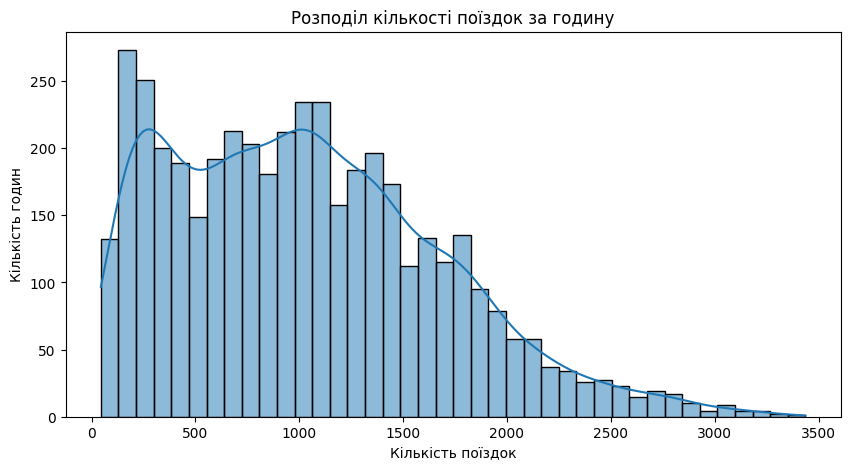

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    target_df['NumberOfTrips'],
    bins=40,
    kde=True
)

plt.title('Розподіл кількості поїздок за годину')
plt.xlabel('Кількість поїздок')
plt.ylabel('Кількість годин')

plt.show()

4 — статистика Target

In [30]:
target_df['NumberOfTrips'].describe()

,NumberOfTrips
count,4391.000000
mean,1032.641084
std,645.217823
min,45.000000
25%,500.000000
50%,978.000000
75%,1442.000000
max,3437.000000


5 — максимальний попит

In [31]:
target_df.loc[target_df['NumberOfTrips'].idxmax()]

,3978
Date,2014-09-13
Hour,18
Day,13
DayOfWeek,Saturday
NumberOfTrips,3437


🚕 Максимальний попит у нашому датасеті був 13 вересня 2014 року о 18:00 — 3437 поїздок за годину.

6 — середній попит за годинами

In [32]:
hour_demand = (
    target_df.groupby('Hour')['NumberOfTrips']
    .mean()
    .reset_index()
)

hour_demand.sort_values(
    'NumberOfTrips',
    ascending=False
)

,Hour,NumberOfTrips
17,17,1837.103825
18,18,1774.202186
16,16,1712.568306
19,19,1609.360656
20,20,1555.213115
21,21,1538.032787
15,15,1505.278689
22,22,1321.628415
14,14,1260.245902
13,13,1070.366120


7 — графік попиту за годинами

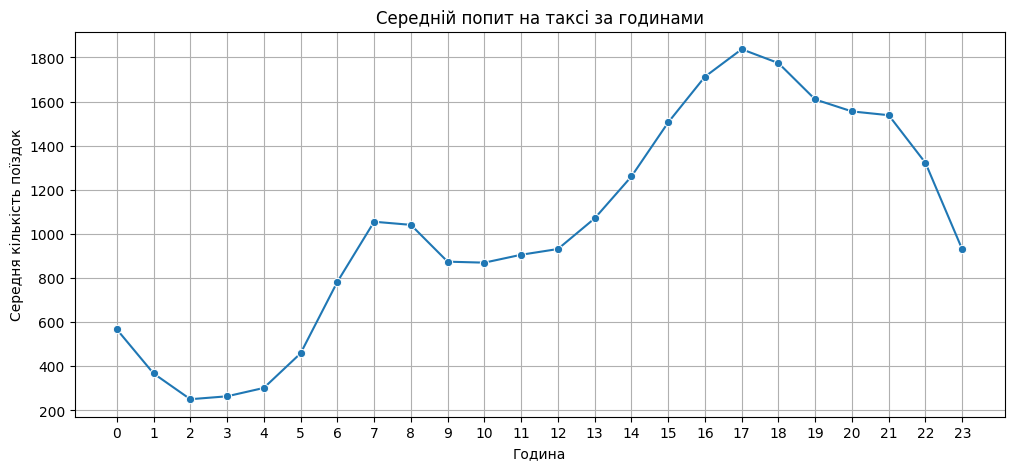

In [33]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hour_demand,
    x='Hour',
    y='NumberOfTrips',
    marker='o'
)

plt.title('Середній попит на таксі за годинами')
plt.xlabel('Година')
plt.ylabel('Середня кількість поїздок')

plt.xticks(range(24))
plt.grid()

plt.show()

8 — середній попит за днями тижня

In [34]:
day_demand = (
    target_df.groupby('DayOfWeek')['NumberOfTrips']
    .mean()
    .sort_values(ascending=False)
)

day_demand

,NumberOfTrips
DayOfWeek,
Thursday,1210.168269
Friday,1187.722756
Wednesday,1116.166667
Saturday,1035.439103
Tuesday,1025.948995
Monday,867.743590
Sunday,785.544872


10 — залежність дня тижня та години

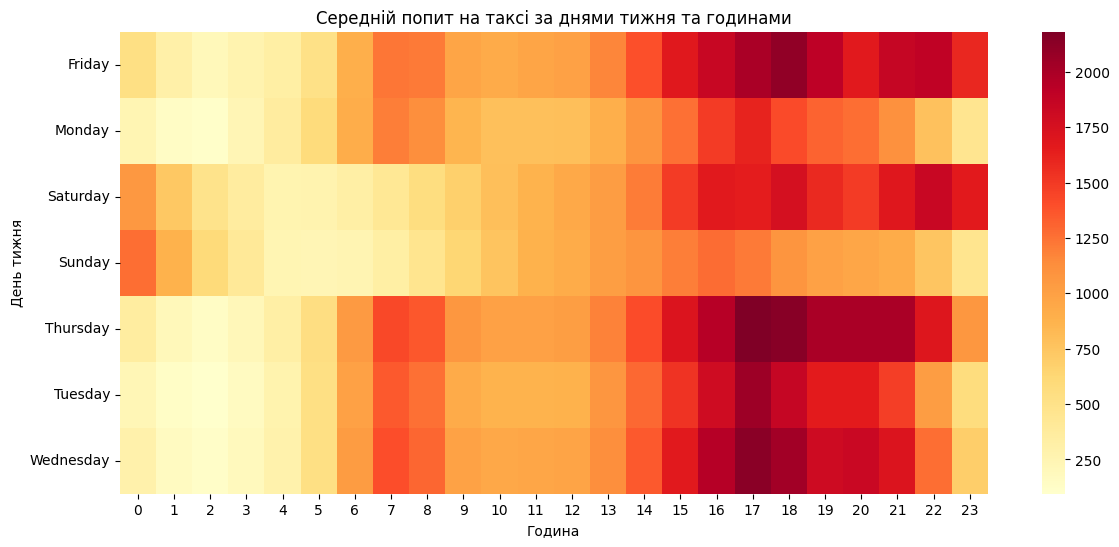

In [35]:
heatmap_data = target_df.pivot_table(
    index='DayOfWeek',
    columns='Hour',
    values='NumberOfTrips',
    aggfunc='mean'
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd'
)

plt.title('Середній попит на таксі за днями тижня та годинами')
plt.xlabel('Година')
plt.ylabel('День тижня')

plt.show()

11 — кореляція

In [36]:
correlation = target_df[
    ['Hour', 'Day', 'NumberOfTrips']
].corr()

correlation

,Hour,Day,NumberOfTrips
Hour,1.000000,-0.000612,0.629294
Day,-0.000612,1.000000,0.034995
NumberOfTrips,0.629294,0.034995,1.000000


12 — візуалізація кореляції

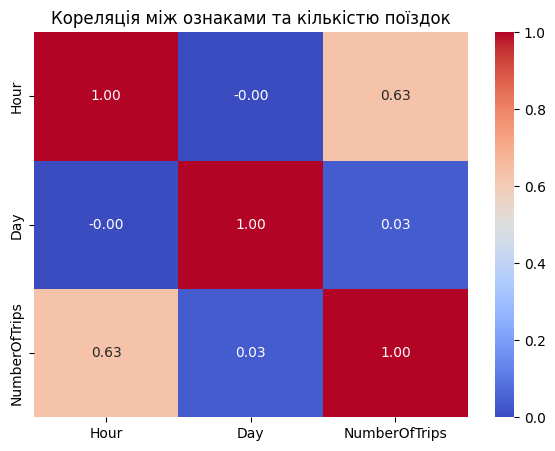

In [37]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Кореляція між ознаками та кількістю поїздок')

plt.show()

13 — формуємо X та y

Тут ми розділяємо дані на:

X — ознаки, за якими модель робитиме прогноз;
y — Target, який модель повинна передбачити.

In [38]:
X = target_df[
    ['Hour', 'Day', 'DayOfWeek']
]

y = target_df['NumberOfTrips']

print("Розмір X:", X.shape)
print("Розмір y:", y.shape)

Розмір X: (4391, 3)
Розмір y: (4391,)


14 — перевіряємо X

In [39]:
X.head()

,Hour,Day,DayOfWeek
0,0,1,Tuesday
1,1,1,Tuesday
2,2,1,Tuesday
3,3,1,Tuesday
4,4,1,Tuesday


15 — перевіряємо Target

In [40]:
y.head()

,NumberOfTrips
0,138
1,66
2,53
3,93
4,166


16 — розділяємо дані на Train і Test
* Train — дані, на яких модель навчатиметься;
* Test — дані, на яких ми перевіримо мод

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Навчальна вибірка:", X_train.shape)
print("Тестова вибірка:", X_test.shape)

Навчальна вибірка: (3512, 3)
Тестова вибірка: (879, 3)


17 — імпортуємо інструменти для Pipeline

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

* Hour і Day → числові;
* DayOfWeek → категоріальна;
* категоріальну змінну кодуємо через OneHotEncoder;
* числові масштабуємо через StandardScaler

Ми вже зробили:

✅ завантажили 4,5 млн поїздок
✅ створили NumberOfTrips — наш Target
✅ проаналізували Target
✅ подивилися розподіл
✅ знайшли максимальний попит
✅ дослідили попит за годинами
✅ дослідили попит за днями
✅ зробили кореляцію
✅ створили X та y
✅ розділили дані на Train і Test

Тепер починається найцікавіша частина — власне машинне навчання. 🤖

Наступні комірки створять Pipeline, а потім ми зробимо:

Pipeline
   ↓
RandomForestRegressor
   ↓
Навчання
   ↓
Прогноз
   ↓
MAE / RMSE / R²
   ↓
GridSearchCV